# Menstrual Cycle Prediction & PCOS Risk Assessment

**Course Project — Part 1**

This notebook covers dataset loading, preprocessing, exploratory data analysis, and the first machine learning model (Random Forest Regressor) applied to predict menstrual cycle length using two real-world medical datasets.

## 1. Import Libraries

Importing all required libraries for data manipulation, visualization, and machine learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Dataset Description and Loading

### Dataset A — FedCycleData (Menstrual Cycle Tracker)

This dataset contains real longitudinal menstrual cycle records. Each row represents one cycle for one patient. Key features include cycle length, menses length, BMI, and age.

We load the CSV, convert key columns to numeric, and engineer lag/rolling features (previous cycle length, rolling mean, rolling std) to capture each patient's personal cycle history.

In [ ]:
#set A
raw = pd.read_csv('FedCycleData071012 (2).csv')


# Convert to numeric
raw['Age']            = pd.to_numeric(raw['Age'],            errors='coerce')
raw['BMI']            = pd.to_numeric(raw['BMI'],            errors='coerce')
raw['LengthofMenses'] = pd.to_numeric(raw['LengthofMenses'], errors='coerce')

In [ ]:
raw = raw.sort_values(by=['ClientID', 'CycleNumber'])


raw['Age'] = raw.groupby('ClientID')['Age'].ffill()
raw['Age'] = raw.groupby('ClientID')['Age'].bfill()

raw['BMI'] = raw.groupby('ClientID')['BMI'].ffill()
raw['BMI'] = raw.groupby('ClientID')['BMI'].bfill()


raw['prev_cycle_length'] = raw.groupby('ClientID')['LengthofCycle'].shift(1)


mean_values = raw.groupby('ClientID')['LengthofCycle'].expanding().mean()
mean_values = mean_values.shift(1)
mean_values = mean_values.round(2)

raw['mean_cycle_length'] = mean_values.reset_index(level=0, drop=True)


std_values = raw.groupby('ClientID')['LengthofCycle'].expanding().std()
std_values = std_values.shift(1)
std_values = std_values.fillna(0)
std_values = std_values.round(2)

raw['std_cycle_length'] = std_values.reset_index(level=0, drop=True)


df_cycle = raw.dropna(subset=['prev_cycle_length', 'Age', 'BMI']).copy()

In [ ]:
df_cycle = df_cycle[
    [
        'ClientID',
        'CycleNumber',
        'Age',
        'BMI',
        'LengthofCycle',
        'prev_cycle_length',
        'mean_cycle_length',
        'std_cycle_length',
        'LengthofMenses'
    ]
]


df_cycle = df_cycle.rename(
    columns={
        'Age'          : 'age',
        'BMI'          : 'bmi',
        'LengthofCycle': 'cycle_length',
        'LengthofMenses': 'period_length'
    }
)


df_cycle['days_to_next_period'] = df_cycle['cycle_length']


df_cycle['is_irregular'] = (
    (df_cycle['cycle_length'] < 21) |
    (df_cycle['cycle_length'] > 35)
).astype(int)



df_cycle = df_cycle.reset_index(drop=True)


print("Dataset A (Cycle Tracker — REAL DATA) loaded successfully")
print("Unique patients :", df_cycle['ClientID'].nunique())
print(
    "Shape           :", df_cycle.shape,
    "→", df_cycle.shape[0], "rows and", df_cycle.shape[1], "columns"
)
print(df_cycle.head(6))

### Dataset B — PCOS Clinical Data

This dataset contains clinical and hormonal measurements for patients, with a binary label indicating PCOS diagnosis. Features include hormonal markers (AMH, LH, FSH), lifestyle factors, and physical symptoms such as weight gain, hair growth, and skin darkening.

In [ ]:
df_pcos_raw = pd.read_excel(
    'PCOS_data_without_infertility.xlsx',
    sheet_name='Full_new'
)


pcos_cols = [
    'PCOS (Y/N)',
    'BMI',
    'AMH(ng/mL)',
    'LH(mIU/mL)',
    'FSH(mIU/mL)',
    'FSH/LH',
    'Cycle length(days)',
    'Follicle No. (L)',
    'Follicle No. (R)',
    'Weight gain(Y/N)',
    'hair growth(Y/N)',
    'Skin darkening (Y/N)',
    'Hair loss(Y/N)',
    'Pimples(Y/N)',
    'Fast food (Y/N)',
    'Reg.Exercise(Y/N)'
]

df_pcos = df_pcos_raw[pcos_cols].copy()


df_pcos['AMH(ng/mL)'] = pd.to_numeric(df_pcos['AMH(ng/mL)'], errors='coerce')
df_pcos['FSH/LH']     = pd.to_numeric(df_pcos['FSH/LH'],     errors='coerce')


print("Dataset B (PCOS Clinical Data) loaded successfully")
print("Shape:", df_pcos.shape)
print(
    "PCOS positive cases:",
    int(df_pcos['PCOS (Y/N)'].sum()),
    f"({df_pcos['PCOS (Y/N)'].mean() * 100:.1f}%)"
)
print(df_pcos.head(4))

## 3. Preprocessing

### 3.1 Missing Values

We first identify missing values in both datasets, then fill them using **median imputation** — a robust strategy that is not affected by outliers.

In [ ]:
print("=" * 50)
print("Dataset A: Missing Values")
print("=" * 50)

missing_a = df_cycle.isnull().sum()

print(missing_a[missing_a > 0].to_string() if missing_a.sum() > 0 else "No missing values found.")

total_missing_a = df_cycle.isnull().sum().sum()
total_values_a  = df_cycle.size

print(
    "Total missing:",
    total_missing_a,
    "out of",
    total_values_a,
    f"({total_missing_a / total_values_a * 100:.2f}%)"
)


print()
print("=" * 50)
print("Dataset B: Missing Values")
print("=" * 50)

missing_b = df_pcos.isnull().sum()

print(missing_b[missing_b > 0].to_string() if missing_b.sum() > 0 else "No missing values found.")

total_missing_b = df_pcos.isnull().sum().sum()
total_values_b  = df_pcos.size

print(
    "Total missing:",
    total_missing_b,
    "out of",
    total_values_b,
    f"({total_missing_b / total_values_b * 100:.2f}%)"
)


#handling missing vals
# Fill missing values using median for Dataset A
num_cols_a = df_cycle.select_dtypes(include='number').columns

for col in num_cols_a:
    if df_cycle[col].isnull().sum() > 0:
        median_value = df_cycle[col].median()
        df_cycle[col] = df_cycle[col].fillna(median_value)

#set B
num_cols_b = df_pcos.select_dtypes(include='number').columns

for col in num_cols_b:
    if df_pcos[col].isnull().sum() > 0:
        median_value = df_pcos[col].median()
        df_pcos[col] = df_pcos[col].fillna(median_value)


print("Dataset A remaining missing:", df_cycle.isnull().sum().sum())
print("Dataset B remaining missing:", df_pcos.isnull().sum().sum())
print("All missing values have been filled using median imputation.")

### 3.2 Outlier Detection & Handling

Boxplots are used to visually inspect the distribution of key numerical features and identify potential outliers. We then use the **IQR (Interquartile Range)** method to quantify outliers and apply **Winsorizing** (clipping values to IQR bounds) to handle them without removing data.

In [ ]:
#box plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Boxplots for Outlier Detection — Dataset A', fontweight='bold')

cols_a = ['cycle_length', 'bmi', 'period_length']

for ax, col in zip(axes, cols_a):
    ax.boxplot(
        df_cycle[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor='#4C9BE8', alpha=0.7),
        medianprops=dict(color='black', linewidth=2)
    )
    ax.set_title(col)
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

In [ ]:
#outlier detection

print("Outlier Count (IQR method) — Dataset A")

cols_a_out = ['cycle_length', 'days_to_next_period', 'bmi']

for col in cols_a_out:
    Q1  = df_cycle[col].quantile(0.25)
    Q3  = df_cycle[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df_cycle[col] < lower) | (df_cycle[col] > upper)).sum()

    print(f"  {col}: {outliers} outliers")


print()
print("Outlier Count (IQR method) — Dataset B")

cols_b_out = ['BMI', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'AMH(ng/mL)', 'Cycle length(days)']

for col in cols_b_out:
    Q1  = df_pcos[col].quantile(0.25)
    Q3  = df_pcos[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df_pcos[col] < lower) | (df_pcos[col] > upper)).sum()

    print(f"  {col}: {outliers} outliers")


print()
print("Strategy: Winsorizing (clipping values to IQR bounds)")


#winsorize

def winsorize(df, cols):
    for col in cols:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df[col] = df[col].clip(lower_bound, upper_bound)

    return df


df_cycle = winsorize(
    df_cycle,
    ['cycle_length', 'days_to_next_period', 'bmi', 'period_length']
)

df_pcos = winsorize(
    df_pcos,
    ['BMI', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'AMH(ng/mL)', 'Cycle length(days)']
)

print("Outliers capped in both datasets.")

### 3.3 Data Type Conversion

Binary symptom columns in Dataset B are converted to integer type (0/1) to ensure compatibility with machine learning models.

In [ ]:
binary_cols_pcos = [
    'PCOS (Y/N)',
    'Weight gain(Y/N)',
    'hair growth(Y/N)',
    'Skin darkening (Y/N)',
    'Hair loss(Y/N)',
    'Pimples(Y/N)',
    'Fast food (Y/N)',
    'Reg.Exercise(Y/N)'
]

for col in binary_cols_pcos:
    df_pcos[col] = df_pcos[col].fillna(0).astype(int)

# Ensure target variable is integer
df_cycle['is_irregular'] = df_cycle['is_irregular'].astype(int)


print("Dataset A — Key Data Types")
print(
    df_cycle[['cycle_length', 'days_to_next_period', 'bmi', 'is_irregular']]
    .dtypes
    .to_string()
)

print()
print("Dataset B — Key Data Types")
print(
    df_pcos[['BMI', 'AMH(ng/mL)', 'LH(mIU/mL)', 'PCOS (Y/N)']]
    .dtypes
    .to_string()
)

print()
print("All types verified.")

### 3.4 Shape & Descriptive Statistics

We print the shape of both DataFrames and use `.describe()` to obtain summary statistics (mean, std, min, max, quartiles) for all numerical features.

In [ ]:
print(
    f"Dataset A shape: {df_cycle.shape} "
    f"({df_cycle.shape[0]} cycle records, {df_cycle.shape[1]} features)"
)

print(
    f"Dataset B shape: {df_pcos.shape} "
    f"({df_pcos.shape[0]} patients, {df_pcos.shape[1]} features)"
)


print()
print("Dataset A: Descriptive Statistics")
print(df_cycle.describe().round(2).to_string())

print()
print("Dataset B: Descriptive Statistics")
print(df_pcos.describe().round(2).to_string())

## 4. Data Visualization

### 4.1 Histograms , Numerical Features (Dataset A)

Histograms show the distribution of each numerical feature. We check for normality, skewness, and any remaining anomalies after preprocessing.

In [ ]:
# Histograms 

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(
    'Distribution of Numerical Features — Dataset A',
    fontweight='bold',
    fontsize=14
)

num_cols = [
    'cycle_length',
    'prev_cycle_length',
    'mean_cycle_length',
    'std_cycle_length',
    'bmi',
    'period_length'
]

colors = ['steelblue', 'teal', 'darkcyan', 'slateblue', 'coral', 'goldenrod']

for ax, col, color in zip(axes.flat, num_cols, colors):
    ax.hist(df_cycle[col], bins=28, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Observation: cycle_length and days_to_next_period are approximately normally distributed.")
print("std_cycle_length is right-skewed — some patients have highly variable cycle histories.")
print("BMI shows a slight right skew, common in health datasets.")

### 4.2 Cycle Irregularity Analysis (Dataset A)

Cycles shorter than 21 days or longer than 35 days are classified as irregular. We visualize the distribution of cycle lengths with irregularity boundaries, compare regular vs irregular cycles using boxplots, and show the overall irregularity rate.

In [ ]:
# Cycle Irregularity

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Cycle Length Analysis', fontweight='bold')


# Histogram with irregular boundary lines
axes[0].hist(
    df_cycle['cycle_length'],
    bins=30,
    color='steelblue',
    edgecolor='white'
)

axes[0].axvline(21, linestyle='--', color='tomato', label='Below 21 (Irregular)')
axes[0].axvline(35, linestyle='--', color='orange', label='Above 35 (Irregular)')
axes[0].set_title('Cycle Length Distribution')
axes[0].set_xlabel('Cycle Length (days)')
axes[0].set_ylabel('Frequency')
axes[0].legend()


# Boxplot comparing regular vs irregular
regular_cycles   = df_cycle[df_cycle['is_irregular'] == 0]['cycle_length']
irregular_cycles = df_cycle[df_cycle['is_irregular'] == 1]['cycle_length']

axes[1].boxplot(
    [regular_cycles, irregular_cycles],
    labels=['Regular', 'Irregular']
)
axes[1].set_title('Regular vs Irregular Cycles')
axes[1].set_ylabel('Cycle Length (days)')


# Pie chart
counts = df_cycle['is_irregular'].value_counts().sort_index()

axes[2].pie(
    counts,
    labels=['Regular', 'Irregular'],
    autopct='%1.1f%%',
    startangle=90
)
axes[2].set_title('Irregularity Rate')


plt.tight_layout()
plt.show()

regular_pct = (df_cycle['is_irregular'] == 0).mean() * 100

print("Regular cycles  :", (df_cycle['is_irregular'] == 0).sum(), f"({regular_pct:.1f}%)")
print("Irregular cycles:", (df_cycle['is_irregular'] == 1).sum(), f"({100 - regular_pct:.1f}%)")

### 4.3 Symptom Prevalence — Categorical Features (Dataset B)

Bar charts compare the prevalence of PCOS-related symptoms (weight gain, hair growth, skin darkening, hair loss, pimples) between PCOS-positive and PCOS-negative patients.

In [ ]:
symptom_cols = [
    'Weight gain(Y/N)',
    'hair growth(Y/N)',
    'Skin darkening (Y/N)',
    'Hair loss(Y/N)',
    'Pimples(Y/N)'
]

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Symptom Prevalence in PCOS vs Non-PCOS Patients', fontweight='bold')

for ax, col in zip(axes, symptom_cols):

    pcos_yes = df_pcos[df_pcos['PCOS (Y/N)'] == 1][col].mean() * 100
    pcos_no  = df_pcos[df_pcos['PCOS (Y/N)'] == 0][col].mean() * 100

    ax.bar(
        ['Non-PCOS', 'PCOS'],
        [pcos_no, pcos_yes],
        color=['steelblue', 'coral']
    )

    ax.set_title(col.replace('(Y/N)', '').strip())
    ax.set_ylabel('% of patients')
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("Key insight: PCOS patients show higher symptom prevalence across all categories.")
print("Hair growth and weight gain show the strongest differences between groups.")

### 4.4 PCOS Class Distribution (Dataset B)

A pie chart shows the class balance between PCOS-positive and PCOS-negative cases. A histogram compares cycle length distributions between the two groups.

In [ ]:
# PCOS Class Distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('PCOS Dataset Analysis', fontweight='bold')


# Pie chart 
pcos_counts = df_pcos['PCOS (Y/N)'].value_counts().sort_index()

axes[0].pie(
    pcos_counts,
    labels=['No PCOS', 'PCOS'],
    autopct='%1.1f%%',
    colors=['steelblue', 'coral'],
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)
axes[0].set_title('PCOS Class Distribution')


# cycle length by PCOS status
no_pcos  = df_pcos[df_pcos['PCOS (Y/N)'] == 0]['Cycle length(days)']
yes_pcos = df_pcos[df_pcos['PCOS (Y/N)'] == 1]['Cycle length(days)']

axes[1].hist(no_pcos,  bins=20, alpha=0.7, label='No PCOS', color='steelblue')
axes[1].hist(yes_pcos, bins=20, alpha=0.7, label='PCOS',    color='coral')

axes[1].set_title('Cycle Length Distribution by PCOS Status')
axes[1].set_xlabel('Cycle Length (days)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.5 Scatter Plots — Feature Relationships

Scatter plots are used to visualize relationships between pairs of numerical features. We examine:
- Previous cycle length vs next period date
- BMI vs cycle length (coloured by irregularity)
- LH vs AMH (coloured by PCOS status)

In [ ]:
# Scatter Plots

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Feature Relationships Analysis', fontweight='bold')


# Previous cycle length vs days to next period
axes[0].scatter(
    df_cycle['prev_cycle_length'],
    df_cycle['days_to_next_period'],
    alpha=0.3,
    s=12,
    color='steelblue'
)

axes[0].set_title('Previous Cycle vs Next Period (Dataset A)')
axes[0].set_xlabel('Previous Cycle Length (days)')
axes[0].set_ylabel('Days to Next Period')


# BMI vs Cycle Length coloured by irregularity
colors_irregular = df_cycle['is_irregular'].map({0: 'steelblue', 1: 'coral'})

axes[1].scatter(
    df_cycle['bmi'],
    df_cycle['cycle_length'],
    c=colors_irregular,
    alpha=0.3,
    s=12
)

axes[1].set_title('BMI vs Cycle Length')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Cycle Length (days)')

axes[1].legend(
    handles=[
        Patch(color='steelblue', label='Regular'),
        Patch(color='coral',     label='Irregular')
    ]
)


# LH vs AMH coloured by PCOS status
colors_pcos = df_pcos['PCOS (Y/N)'].map({0: 'steelblue', 1: 'coral'})

axes[2].scatter(
    df_pcos['LH(mIU/mL)'],
    df_pcos['AMH(ng/mL)'],
    c=colors_pcos,
    alpha=0.5,
    s=15
)

axes[2].set_title('LH vs AMH (PCOS Analysis)')
axes[2].set_xlabel('LH (mIU/mL)')
axes[2].set_ylabel('AMH (ng/mL)')

axes[2].legend(
    handles=[
        Patch(color='steelblue', label='No PCOS'),
        Patch(color='coral',     label='PCOS')
    ]
)


plt.tight_layout()
plt.show()

print("Insight 1: Previous cycle length has a strong positive relationship with next cycle length.")
print("Insight 2: BMI shows mild separation between regular and irregular cycles.")
print("Insight 3: LH and AMH show clear clustering by PCOS status.")

### 4.6 Pair Plots — All Feature Relationships

Seaborn pair plots display pairwise relationships between all key features in a matrix format, with colour coding by target variable (irregularity for Dataset A, PCOS status for Dataset B).

In [ ]:
pair_cols_a = [
    'cycle_length',
    'prev_cycle_length',
    'mean_cycle_length',
    'bmi',
    'days_to_next_period',
    'is_irregular'
]

sample_df = df_cycle[pair_cols_a].sample(400, random_state=42)

g = sns.pairplot(
    sample_df,
    hue='is_irregular',
    palette={0: 'steelblue', 1: 'coral'},
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kind='kde'
)

g.figure.suptitle(
    'Pairwise Feature Relationships — Dataset A',
    y=1.02,
    fontweight='bold'
)

plt.show()


pair_cols_b = [
    'BMI',
    'AMH(ng/mL)',
    'LH(mIU/mL)',
    'FSH(mIU/mL)',
    'Cycle length(days)',
    'PCOS (Y/N)'
]

g2 = sns.pairplot(
    df_pcos[pair_cols_b],
    hue='PCOS (Y/N)',
    palette={0: 'steelblue', 1: 'coral'},
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kind='kde'
)

g2.figure.suptitle(
    'Pairwise Feature Relationships — PCOS Dataset',
    y=1.02,
    fontweight='bold'
)

plt.show()

print("Insight: AMH and LH show the strongest separation between PCOS and non-PCOS patients.")

## 5. Methodology , Model 1: Random Forest Regressor (Dataset A)

Based on the exploratory analysis, we use a **Random Forest Regressor** to predict the number of days until the next menstrual period.

**Why Random Forest?**
- Captures non-linear relationships between cycle history features and cycle length
- Robust to outliers due to ensemble averaging
- Provides feature importance scores
- Works well with the engineered rolling features (prev, mean, std cycle length)

The dataset is split into 80% training and 20% testing sets.

In [ ]:
feature_cols_a = [
    'prev_cycle_length',
    'mean_cycle_length',
    'std_cycle_length',
    'age',
    'bmi',
    'period_length',
    'CycleNumber',      
]

target_a = 'days_to_next_period'

X_a = df_cycle[feature_cols_a]
y_a = df_cycle[target_a]

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_a,
    y_a,
    test_size=0.2,
    random_state=42
)

print("Dataset Split Summary:")
print(f"  Training samples : {len(X_train_a)}")
print(f"  Testing samples  : {len(X_test_a)}")
print(f"  Features used    : {feature_cols_a}")

### 5.1 Model Training & Evaluation

We train the Random Forest Regressor and evaluate it using:
- **MAE (Mean Absolute Error)** — average prediction error in days
- **R² Score** — proportion of variance explained by the model

In [ ]:
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42
)

# Train the model
rf_reg.fit(X_train_a, y_train_a)

# Predict on test data
y_pred_a = rf_reg.predict(X_test_a)

# Evaluate performance
mae = mean_absolute_error(y_test_a, y_pred_a)
r2  = r2_score(y_test_a, y_pred_a)


print("Model 1 — Random Forest Regressor Results")
print("-" * 45)
print(f"Mean Absolute Error (MAE) : {mae:.2f} days")
print(f"R² Score                  : {r2:.4f}")

print()
print("Interpretation:")
print(f"  On average, predictions differ by about {mae:.1f} days from the actual cycle length.")
print(f"  The model explains approximately {r2 * 100:.0f}% of the variance in cycle length.")

### 5.2 Actual vs Predicted & Residual Analysis

We plot actual vs predicted values to visualize model accuracy, and the residual distribution to check whether prediction errors are centered around zero.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fig.suptitle(
    'Model 1 — Random Forest Regressor Performance',
    fontsize=13,
    fontweight='bold'
)


# Plot 1: Actual vs Predicted scatter
axes[0].scatter(
    y_test_a,
    y_pred_a,
    alpha=0.4,
    s=18,
    color='steelblue'
)

lims = [y_test_a.min(), y_test_a.max()]

axes[0].plot(
    lims,
    lims,
    linestyle='--',
    linewidth=1.5,
    color='red',
    label='Perfect prediction'
)

axes[0].set_xlabel('Actual Days to Next Period')
axes[0].set_ylabel('Predicted Days')
axes[0].set_title(f'Actual vs Predicted  (MAE={mae:.2f}, R²={r2:.3f})')
axes[0].legend()


# Residual distribution
residuals = y_test_a - y_pred_a

axes[1].hist(
    residuals,
    bins=35,
    color='slateblue',
    edgecolor='white',
    alpha=0.85
)

axes[1].axvline(
    0,
    linestyle='--',
    linewidth=1.5,
    color='tomato'
)

axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')


plt.tight_layout()
plt.show()

### 5.3 Feature Importance

A horizontal bar chart shows which features contributed most to the model's predictions.

In [ ]:
importance_df = pd.DataFrame(
    {
        'Feature'   : feature_cols_a,
        'Importance': rf_reg.feature_importances_
    }
)

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color='steelblue',
    alpha=0.85
)

plt.xlabel('Feature Importance (Mean Decrease in Impurity)')
plt.title(
    'Model 1 — Feature Importances\n'
    '(Features used to predict next period date)',
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

print("Key Insight:")
print("  prev_cycle_length and mean_cycle_length are the strongest predictors.")
print("  A patient's own cycle history is the best indicator of the next period date.")

### 5.4 Irregularity Flagging

Patients whose predicted cycle length falls outside the normal range (< 21 or > 35 days) are flagged as irregular. These flagged patients would be passed to Model 2 (Logistic Regression on Dataset B) for PCOS risk assessment in the next phase of the project.

In [ ]:
 #Irregularity Flagging 

pred_df = pd.DataFrame(
    {
        'actual_days'      : y_test_a.values,
        'predicted_days'   : np.round(y_pred_a, 1),
        'flagged_irregular': (y_test_a.values < 21) | (y_test_a.values > 35)
    }
)

n_flagged = pred_df['flagged_irregular'].sum()
total     = len(pred_df)


print("Irregularity Detection Summary")
print("-" * 35)
print(f"Flagged as irregular : {n_flagged} / {total}")
print(f"Irregularity rate    : {n_flagged / total * 100:.1f}%")

print()
print("Sample Predictions (first 10 rows):")
print(pred_df.head(10).to_string(index=False))

print()
print("Note:")
print("Patients flagged as irregular (predicted cycle < 21 or > 35 days)")
print("would proceed to Model 2 (Random Forest Classifier) for PCOS risk assessment.")

# Training Logistic Regression



Train test split: 80/20 with stratification.
Data Set has 33 % PCOS patients and 67 % donot 
testing data should have same proportion so we use stratification

**Why Logistic Regression**

-Gold standard in Medical industry <br>
-Efficient and LightWeight <br>
-instead of yes/no, gives probability <br>


**Data split** <br>
-X_train = features to train the moddle <br>
-Y_train = PCOS(Y/N) (target the model is trying to predict) <br>
-X_test = Features given to model to make a prediction <br>
-Y_test = PCOS(Y/N) to check the predictions 





In [71]:
feature_cols = [
    'BMI', 'AMH(ng/mL)', 'LH(mIU/mL)', 'FSH(mIU/mL)', 'FSH/LH', 
    'Cycle length(days)', 'Follicle No. (L)', 'Follicle No. (R)', 
    'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 
    'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)'
]

X = df_pcos[feature_cols]
y = df_pcos['PCOS (Y/N)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

#scale features

scaler = StandardScaler()

#  Fit and Transform the Training Data
# 'fit' calculates the mean and standard deviation of each feature
# 'transform' applies the formula: z = (x - u) / s
X_train_scaled = scaler.fit_transform(X_train)

# Transform the Testing Data
# CRITICAL: We only use 'transform' here. 
# We must use the mean/std from the training set to treat the test set as "unseen".
X_test_scaled = scaler.transform(X_test)

print("Data scaling successful.")

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log_reg = log_reg.predict(X_test_scaled)
print("Logistic Regression model training complete.")



test_summary = pd.DataFrame({
    'Actual PCOS': y_test.values[:10],
    'Predicted PCOS': y_pred_log_reg[:10],
    'Confidence (%)': (log_reg.predict_proba(X_test_scaled)[:, 1][:10] * 100).round(2)
})

print("\n--- Detailed Test Set Samples ---")
print(test_summary)


# Check which features have the strongest influence
print("\nFeature Weights from Logistic Regression:")
weights = pd.DataFrame({'Feature': feature_cols, 'Weight': log_reg.coef_[0]})
print(weights.sort_values(by='Weight', ascending=False))

Data scaling successful.
Logistic Regression model training complete.

--- Detailed Test Set Samples ---
   Actual PCOS  Predicted PCOS  Confidence (%)
0            1               0            0.37
1            0               0           24.68
2            0               0           11.02
3            1               1           97.25
4            0               0            0.70
5            1               1           99.75
6            1               0           29.12
7            0               0            9.47
8            1               1           84.60
9            0               0            2.62

Feature Weights from Logistic Regression:
                 Feature    Weight
7       Follicle No. (R)  1.545809
6       Follicle No. (L)  0.744417
9       hair growth(Y/N)  0.686814
10  Skin darkening (Y/N)  0.604002
8       Weight gain(Y/N)  0.591089
12          Pimples(Y/N)  0.389422
11        Hair loss(Y/N)  0.192310
1             AMH(ng/mL)  0.182852
13       Fast food (

In [ ]:

def predict_pcos_risk(patient_dict):
    """
    Takes a dictionary of patient data, scales it, 
    and returns the Logistic Regression diagnosis.
    """
    # 1. Convert to DataFrame and FORCE the correct column order
    # This is critical to ensure follicles aren't read as BMI
    patient_df = pd.DataFrame([patient_dict])[feature_cols]
    
    # 2. Scale the data using the fitted scaler
    patient_scaled = scaler.transform(patient_df)
    
    # 3. Get the raw probability and the final prediction
    prob_pcos = log_reg.predict_proba(patient_scaled)[0][1]
    prediction = log_reg.predict(patient_scaled)[0]
    
    # 4. Format and print the output
    status = "PCOS Positive" if prediction == 1 else "PCOS Negative"
    print(f"--- Diagnostic Result ---")
    print(f"Prediction : {status}")
    print(f"Confidence : {prob_pcos*100:.2f}% (Probability of PCOS)")
    
    

In [93]:
#positive case test (high AMH, high LH, irregular cycle, multiple symptoms)
pcos_test = {
    'BMI': 30.5, 'AMH(ng/mL)': 40.0, 'LH(mIU/mL)': 14.5, 'FSH(mIU/mL)': 4.2, 
    'FSH/LH': 0.28, 'Cycle length(days)': 10, 'Follicle No. (L)': 18, 
    'Follicle No. (R)': 40, 'Weight gain(Y/N)': 1, 'hair growth(Y/N)': 1, 
    'Skin darkening (Y/N)': 1, 'Hair loss(Y/N)': 1, 'Pimples(Y/N)': 1, 
    'Fast food (Y/N)': 1, 'Reg.Exercise(Y/N)': 0
}

predict_pcos_risk(pcos_test)

#Negative case test (normal AMH, normal LH, regular cycle, no symptoms)
non_pcos_test = { 
    'BMI': 40.0, 'AMH(ng/mL)': 10.0, 'LH(mIU/mL)': 5.0, 'FSH(mIU/mL)': 5.5, 
    'FSH/LH': 1.1, 'Cycle length(days)': 20, 'Follicle No. (L)': 11, 
    'Follicle No. (R)': 15, 'Weight gain(Y/N)': 1, 'hair growth(Y/N)': 1, 
    'Skin darkening (Y/N)': 1, 'Hair loss(Y/N)': 1, 'Pimples(Y/N)': 1, 
    'Fast food (Y/N)': 1, 'Reg.Exercise(Y/N)': 0
}
predict_pcos_risk(non_pcos_test)


--- Diagnostic Result ---
Prediction : PCOS Positive
Confidence : 100.00% (Probability of PCOS)
--- Diagnostic Result ---
Prediction : PCOS Negative
Confidence : 39.55% (Probability of PCOS)


np.int64(0)

# Training Random Forest Classifier

Train test split: 80/20 with stratification.
Data Set has 33 % PCOS patients and 67 % donot 
testing data should have same proportion so we use stratification

**Why Random Forest Classifier**

-no scaling needed <br>
-PCOS caused by multiple symptoms so it focuses on collective impact of indicators <br>
-Handles noisy data well every piece of data is treated seperately <br>


**Data split** <br>
-X_train = features to train the moddle <br>
-Y_train = PCOS(Y/N) (target the model is trying to predict) <br>
-X_test = Features given to model to make a prediction <br>
-Y_test = PCOS(Y/N) to check the predictions 





In [100]:

X = df_pcos[feature_cols]
y = df_pcos['PCOS (Y/N)']

# Perform the Split (80% Train, 20% Test)
# stratify=y: Keeps the PCOS vs. Healthy ratio consistent in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Total dataset size: {len(X)} patients")
print(f"Training set: {len(X_train)} patients (used for learning)")
print(f"Testing set: {len(X_test)} patients (used for the final grade)")


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train) #it does not need scaled data, it can handle raw features
y_pred_rf = rf_model.predict(X_test)

print("Random Forest training complete.")

rf_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("--- Random Forest Feature Importance ---")
print(rf_importance.sort_values(by='Importance', ascending=False).to_string(index=False))


# Get the probabilities (Percentage of trees that voted for PCOS)
y_probs_rf = rf_model.predict_proba(X_test)[:, 1]

# Create a comparison table for the first 10 test patients
rf_comparison = pd.DataFrame({
    'Actual_PCOS': y_test.values[:10],
    'RF_Predicted': y_pred_rf[:10],
    'Tree_Vote_Confidence (%)': (y_probs_rf[:10] * 100).round(2)
})

print("\n--- Random Forest: Actual vs. Predicted (First 10 Cases) ---")
print(rf_comparison.to_string(index=False))

Total dataset size: 541 patients
Training set: 432 patients (used for learning)
Testing set: 109 patients (used for the final grade)
Random Forest training complete.
--- Random Forest Feature Importance ---
             Feature  Importance
    Follicle No. (R)    0.231307
    Follicle No. (L)    0.182533
    hair growth(Y/N)    0.080592
          AMH(ng/mL)    0.075963
    Weight gain(Y/N)    0.068502
Skin darkening (Y/N)    0.064034
  Cycle length(days)    0.061508
          LH(mIU/mL)    0.058682
         FSH(mIU/mL)    0.055780
              FSH/LH    0.034091
     Fast food (Y/N)    0.031605
        Pimples(Y/N)    0.028228
      Hair loss(Y/N)    0.015007
   Reg.Exercise(Y/N)    0.012169
                 BMI    0.000000

--- Random Forest: Actual vs. Predicted (First 10 Cases) ---
 Actual_PCOS  RF_Predicted  Tree_Vote_Confidence (%)
           1             0                      11.0
           0             0                      36.0
           0             0                  

In [101]:


def predict_pcos_rf(patient_dict):
    """
    Takes a dictionary of patient data and returns 
    the Random Forest diagnosis (no scaling required).
    """
    # 1. Convert to DataFrame
    patient_df = pd.DataFrame([patient_dict])[feature_cols]
    
    # 2. Get the binary prediction (0 or 1)
    prediction = rf_model.predict(patient_df)[0]
    
    # 3. Get the probability (Percentage of trees that voted 'Yes')
    prob_pcos = rf_model.predict_proba(patient_df)[0][1]
    
    # 4. Format and print the output
    status = "PCOS Positive" if prediction == 1 else "PCOS Negative"
    print(f"--- Random Forest Diagnostic Result ---")
    print(f"Prediction : {status}")
    print(f"Tree Vote  : {prob_pcos*100:.2f}% of trees voted PCOS")
    


In [103]:
# Example Patient (High Risk)
pcos_test_case = {
    'BMI': 30.5, 'AMH(ng/mL)': 11.0, 'LH(mIU/mL)': 14.5, 'FSH(mIU/mL)': 4.2, 
    'FSH/LH': 0.28, 'Cycle length(days)': 45, 'Follicle No. (L)': 18, 
    'Follicle No. (R)': 22, 'Weight gain(Y/N)': 1, 'hair growth(Y/N)': 1, 
    'Skin darkening (Y/N)': 1, 'Hair loss(Y/N)': 1, 'Pimples(Y/N)': 1, 
    'Fast food (Y/N)': 1, 'Reg.Exercise(Y/N)': 0
}


predict_pcos_rf(pcos_test_case)


# A healthy, low-risk profile
pcos_low_risk_case = {
    'BMI': 21.2,
    'AMH(ng/mL)': 1.5,
    'LH(mIU/mL)': 3.8,
    'FSH(mIU/mL)': 6.5,
    'FSH/LH': 1.71,
    'Cycle length(days)': 28,
    'Follicle No. (L)': 4,
    'Follicle No. (R)': 3,
    'Weight gain(Y/N)': 0,
    'hair growth(Y/N)': 0,
    'Skin darkening (Y/N)': 0,
    'Hair loss(Y/N)': 0,
    'Pimples(Y/N)': 0,
    'Fast food (Y/N)': 0,
    'Reg.Exercise(Y/N)': 1
}

# Run the prediction using the Random Forest function
predict_pcos_rf(pcos_low_risk_case)

--- Random Forest Diagnostic Result ---
Prediction : PCOS Positive
Tree Vote  : 95.00% of trees voted PCOS
--- Random Forest Diagnostic Result ---
Prediction : PCOS Negative
Tree Vote  : 2.00% of trees voted PCOS


# Evaluation and comparison of both models


In [108]:

# Helper function to compile metrics
def get_metrics(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }

# Compute results (using predictions generated in your previous notebook cells)
comparison_df = pd.DataFrame([
    get_metrics(y_test, y_pred_log_reg, "Logistic Regression"),
    get_metrics(y_test, y_pred_rf, "Random Forest")
]).set_index("Model")

print("--- Final Performance Metrics ---")
print(comparison_df.round(4))

--- Final Performance Metrics ---
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.8991     0.8788  0.8056    0.8406
Random Forest          0.9174     0.9355  0.8056    0.8657


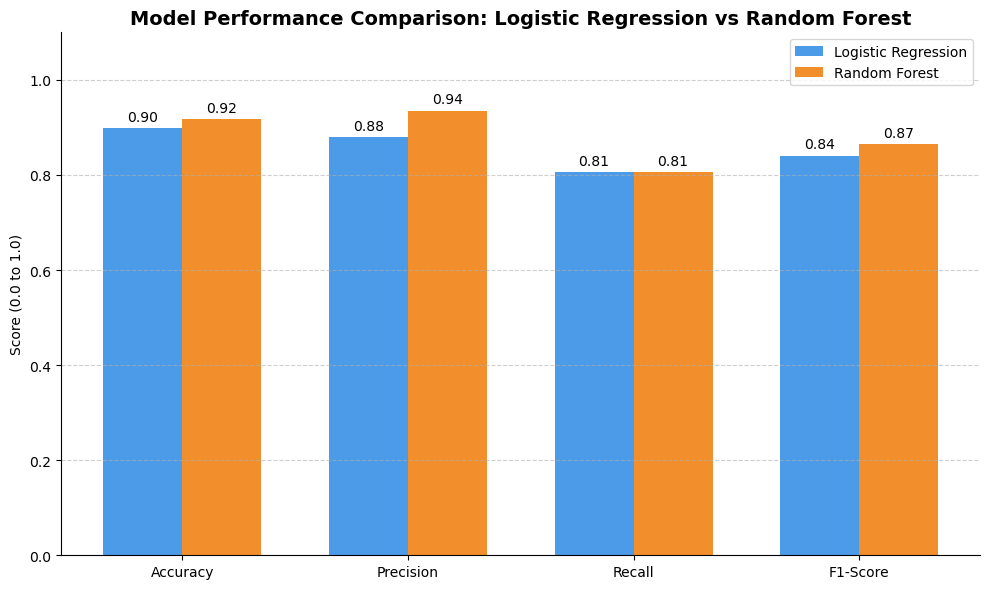

In [110]:
#visualizing the metrics comparison

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Scores for Logistic Regression
lr_scores = [
    accuracy_score(y_test, y_pred_log_reg),
    precision_score(y_test, y_pred_log_reg),
    recall_score(y_test, y_pred_log_reg),
    f1_score(y_test, y_pred_log_reg)
]

rf_scores = [
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf)
]


x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='#4C9BE8')
rects2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest', color='#F28E2B')


ax.set_ylabel('Score (0.0 to 1.0)')
ax.set_title('Model Performance Comparison: Logistic Regression vs Random Forest', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)


def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

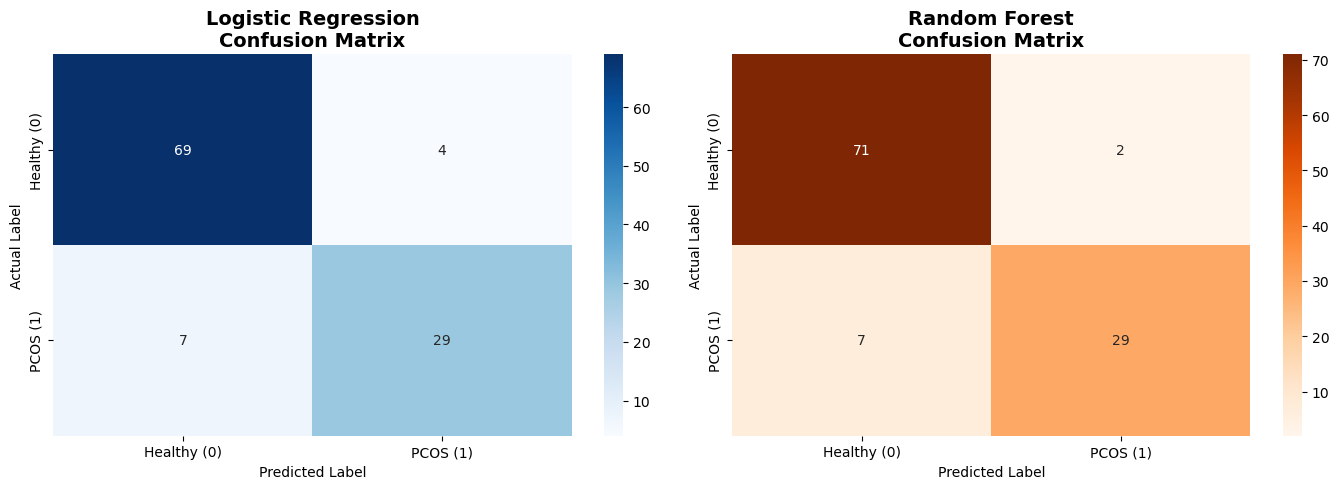

In [115]:
# 1. Compute the Confusion Matrices for both models
cm_log = confusion_matrix(y_test, y_pred_log_reg)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# 2. Create the plotting area
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Logistic Regression Confusion Matrix
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('Actual Label')
axes[0].set_xticklabels(['Healthy (0)', 'PCOS (1)'])
axes[0].set_yticklabels(['Healthy (0)', 'PCOS (1)'])

# Plot Random Forest Confusion Matrix
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('Random Forest\nConfusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('Actual Label')
axes[1].set_xticklabels(['Healthy (0)', 'PCOS (1)'])
axes[1].set_yticklabels(['Healthy (0)', 'PCOS (1)'])

plt.tight_layout()
plt.show()